# Customer Churn Prediction — Stage 3
**Felix · Data Analyst — Predictive Modelling**

## How to use this notebook
Run the cells in order in Google Colab (CPU is sufficient). This notebook is unexecuted: all reported results will be generated by your run. It preserves the original data version and test split, corrects scaling for internal validation, compares three ANN configurations over three random seeds, selects a threshold on validation, and evaluates the selected model on the test set.

**Protocol fixed before evaluation:** select the configuration and threshold with the highest mean validation churn-class F1 across seeds 42, 43 and 44. Ties prefer higher mean precision, then the threshold closest to 0.50. Use seed 42 for the delivered model, without choosing a seed from test performance. F1 balances precision and recall; this is not a claim that it optimises business profit. No cost or contact-budget constraint has been supplied.

**Important:** do not change the selection rule or tune after seeing test results. Three seeds assess training variability on one fixed split, not cross-validation or external validation. The retained model is trained on 4,313 rows with early stopping on 1,079 validation rows; it is intentionally not refitted on all rows, so its chosen threshold remains paired with the same model.

The last cell downloads a ZIP with model, preprocessing, results, figures, architecture PDF, and an English findings brief for Arafat. Also download this executed notebook separately through Colab's File menu. Team review and the group report/video still require human completion.


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import json, random, hashlib, shutil, textwrap, platform
from pathlib import Path
from datetime import datetime, timezone
from urllib.request import urlopen
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score,
    precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display

SEED = 42
SEEDS = [42, 43, 44]
DATA_VERSION = '6d1cb202e66568114f8d9a34a4cdeeb3dffabed3'
BASE_URL = ('https://raw.githubusercontent.com/abedcodes13/'
            'customer-churn-analysis-for-telecommunications-company/'
            f'{DATA_VERSION}/Data_Preparation')
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
OUT = Path('ann_stage3_runs') / RUN_ID / 'Predictive_Modeling'
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
try:
    tf.config.experimental.enable_op_determinism()
except (AttributeError, RuntimeError):
    pass
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__)
print('Outputs:', OUT)


TensorFlow: 2.20.0
Outputs: ann_stage3_runs/20261005T040331Z/Predictive_Modeling


## 1. Data and split verification
Use Tyler's encoded, unscaled dataset. Recreate and check the original train/test split against the supplied labels **and scaled feature values**. Fit the modelling scaler only after making the internal validation split. The reference scaler below is used solely to verify the supplied files; it is never used to train or evaluate the ANN.

This fixes the scaling issue in the draft. Encoding and deduplication are inherited from Tyler. The reduced source has no customer ID, so identical attributes do not prove duplicate customers; discuss that limitation with Tyler. `source_row_index` below is a zero-based row index in the preprocessed dataset, not a customer ID.


In [2]:
from io import BytesIO
source_hashes = {}
def read_source(name):
    payload = urlopen(f'{BASE_URL}/{name}', timeout=60).read()
    source_hashes[name] = hashlib.sha256(payload).hexdigest()
    return pd.read_csv(BytesIO(payload))

data = read_source('ATS_preprocessed_dataset.csv')
X = data.drop(columns='Churn')
y = data['Churn'].astype('int32')
assert data.shape == (6741, 17), 'Unexpected source shape'
assert not data.isna().any().any()
assert np.isfinite(data.to_numpy()).all()
assert set(y.unique()) == {0, 1}
feature_names = X.columns.tolist()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
for labels, name in [(y_train, 'ATS_y_train.csv'), (y_test, 'ATS_y_test.csv')]:
    np.testing.assert_array_equal(labels.to_numpy(), read_source(name)['Churn'])
reference_scaler = StandardScaler().fit(X_train_raw)
for raw, name in [(X_train_raw, 'ATS_X_train_scaled.csv'),
                  (X_test_raw, 'ATS_X_test_scaled.csv')]:
    supplied = read_source(name)
    assert raw.columns.tolist() == supplied.columns.tolist()
    np.testing.assert_allclose(reference_scaler.transform(raw), supplied,
                               rtol=1e-5, atol=1e-6)
del reference_scaler
X_fit_raw, X_val_raw, y_fit, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.20, random_state=SEED, stratify=y_train)
assert set(X_fit_raw.index).isdisjoint(X_val_raw.index)
assert set(X_train_raw.index).isdisjoint(X_test_raw.index)
scaler = StandardScaler().fit(X_fit_raw)
X_fit = scaler.transform(X_fit_raw).astype('float32')
X_val = scaler.transform(X_val_raw).astype('float32')
y_fit_arr = y_fit.to_numpy(dtype='float32')
y_val_arr = y_val.to_numpy(dtype='int32')
for label, raw, target in [('fit', X_fit_raw, y_fit), ('validation', X_val_raw, y_val)]:
    print(f'{label}: {raw.shape}; churn rate {target.mean():.2%}')
print('Reserved test:', X_test_raw.shape)
print('Checks passed. Modelling scaler fitted on training subset only.')
pd.concat([pd.DataFrame({'source_row_index': raw.index, 'split': label})
    for label, raw in [('fit', X_fit_raw), ('validation', X_val_raw), ('test', X_test_raw)]
    ]).to_csv(OUT / 'split_membership.csv', index=False)


fit: (4313, 16); churn rate 26.57%
validation: (1079, 16); churn rate 26.60%
Reserved test: (1349, 16)
Checks passed. Modelling scaler fitted on training subset only.


## 2. Controlled model refinement
Compare (1) the original 32/16 ANN, (2) the same architecture with L2 and dropout to limit overfitting, and (3) the regularised model with balanced class weights to test sensitivity to missed churners. All use Adam, binary crossentropy and early stopping on validation loss. Class weights come only from training labels.

Evaluate all candidates on the same validation split. No test scoring occurs in this section. There are nine training runs; progress prints after each run. Do not rerun individual training cells just to obtain a better score.


In [3]:
CONFIGS = [
    {'name': 'baseline_32_16', 'hidden': [32, 16], 'dropout': 0.0, 'l2': 0.0, 'weighted': False},
    {'name': 'regularised_32_16', 'hidden': [32, 16], 'dropout': 0.20, 'l2': 0.001, 'weighted': False},
    {'name': 'weighted_regularised_32_16', 'hidden': [32, 16], 'dropout': 0.20, 'l2': 0.001, 'weighted': True},
]
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_fit.to_numpy())
class_weights = {0: float(weights[0]), 1: float(weights[1])}

def build_model(cfg, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    layers = [tf.keras.Input(shape=(len(feature_names),), name='customer_features')]
    for i, units in enumerate(cfg['hidden']):
        layers.append(tf.keras.layers.Dense(units, activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(cfg['l2']), name=f'hidden_{i+1}'))
        if cfg['dropout']:
            layers.append(tf.keras.layers.Dropout(cfg['dropout'], name=f'dropout_{i+1}'))
    layers.append(tf.keras.layers.Dense(1, activation='sigmoid', name='churn_probability'))
    model = tf.keras.Sequential(layers, name=cfg['name'])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

def scores(actual, predicted):
    return {'accuracy': accuracy_score(actual, predicted),
            'precision': precision_score(actual, predicted, zero_division=0),
            'recall': recall_score(actual, predicted, zero_division=0),
            'f1': f1_score(actual, predicted, zero_division=0)}

runs = {}
summary_rows = []
for cfg in CONFIGS:
    for seed in SEEDS:
        candidate = build_model(cfg, seed)
        history = candidate.fit(X_fit, y_fit_arr,
            validation_data=(X_val, y_val_arr), epochs=80, batch_size=32,
            class_weight=class_weights if cfg['weighted'] else None,
            callbacks=[tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True)],
            shuffle=True, verbose=0)
        probs = candidate.predict(X_val, verbose=0).ravel()
        best_epoch = int(np.argmin(history.history['val_loss']) + 1)
        runs[(cfg['name'], seed)] = {'probabilities': probs, 'history': history.history,
                                    'best_epoch': best_epoch}
        if seed == SEED:
            candidate.save(OUT / f"candidate_{cfg['name']}.keras")
        pd.DataFrame(history.history).to_csv(
            OUT / f"history_{cfg['name']}_seed{seed}.csv", index=False)
        row = {'configuration': cfg['name'], 'seed': seed, 'best_epoch': best_epoch,
               'epochs_run': len(history.history['loss']),
               **scores(y_val_arr, (probs >= 0.5).astype(int))}
        summary_rows.append(row)
        print(f"Completed {cfg['name']}, seed {seed}: best epoch {best_epoch}; F1@0.5={row['f1']:.4f}")
comparison = pd.DataFrame(summary_rows)
comparison.to_csv(OUT / 'validation_runs_at_050.csv', index=False)
display(comparison)


Completed baseline_32_16, seed 42: best epoch 22; F1@0.5=0.5226
Completed baseline_32_16, seed 43: best epoch 9; F1@0.5=0.5092
Completed baseline_32_16, seed 44: best epoch 5; F1@0.5=0.5108
Completed regularised_32_16, seed 42: best epoch 65; F1@0.5=0.5181
Completed regularised_32_16, seed 43: best epoch 50; F1@0.5=0.5062
Completed regularised_32_16, seed 44: best epoch 34; F1@0.5=0.5328
Completed weighted_regularised_32_16, seed 42: best epoch 41; F1@0.5=0.5863
Completed weighted_regularised_32_16, seed 43: best epoch 47; F1@0.5=0.5917
Completed weighted_regularised_32_16, seed 44: best epoch 41; F1@0.5=0.5994


,configuration,seed,best_epoch,epochs_run,accuracy,precision,recall,f1
0,baseline_32_16,42,22,32,0.784986,0.638191,0.442509,0.522634
1,baseline_32_16,43,9,19,0.776645,0.612745,0.435540,0.509165
2,baseline_32_16,44,5,15,0.769231,0.585586,0.452962,0.510806
3,regularised_32_16,42,65,75,0.777572,0.611374,0.449477,0.518072
4,regularised_32_16,43,50,60,0.779425,0.625641,0.425087,0.506224
5,regularised_32_16,44,34,44,0.782206,0.620370,0.466899,0.532803
6,weighted_regularised_32_16,42,41,51,0.720111,0.483070,0.745645,0.586301
7,weighted_regularised_32_16,43,47,57,0.734013,0.500000,0.724739,0.591750
8,weighted_regularised_32_16,44,41,51,0.731233,0.496568,0.756098,0.599448


## 3. Select configuration and threshold on validation
Thresholds 0.20 to 0.70 in steps of 0.05 are compared using mean F1 across the three seeds. The delivered seed is fixed at 42. This validation search introduces selection optimism, so the final test is kept separate. Precision/recall trade-offs should be discussed with Arafat; do not claim this threshold maximises financial returns.


,configuration,threshold,accuracy_mean,precision_mean,recall_mean,f1_mean,f1_sd
27,weighted_regularised_32_16,0.45,0.708990,0.472891,0.810685,0.597259,0.013967
28,weighted_regularised_32_16,0.50,0.728452,0.493212,0.742160,0.592500,0.006605
1,baseline_32_16,0.25,0.717640,0.481481,0.768873,0.591538,0.005894
12,regularised_32_16,0.25,0.718258,0.481361,0.757259,0.588464,0.006426
11,regularised_32_16,0.20,0.682422,0.448813,0.847851,0.586854,0.003110
2,baseline_32_16,0.30,0.737102,0.504425,0.702671,0.586765,0.011604
26,weighted_regularised_32_16,0.40,0.678715,0.445897,0.853659,0.585742,0.008992
13,regularised_32_16,0.30,0.741427,0.510466,0.678281,0.582276,0.013791
29,weighted_regularised_32_16,0.55,0.742663,0.512796,0.671312,0.581213,0.003368
3,baseline_32_16,0.35,0.753784,0.531498,0.638792,0.579937,0.015177


LOCKED selection: weighted_regularised_32_16 | threshold: 0.45 | seed: 42
Selected model validation metrics: {'accuracy': 0.70064874884152, 'precision': 0.463855421686747, 'recall': 0.8048780487804879, 'f1': 0.5885350318471337}


Model: "weighted_regularised_32_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ churn_probability (Dense)       │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269 (12.77 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,180 (8.52 KB)

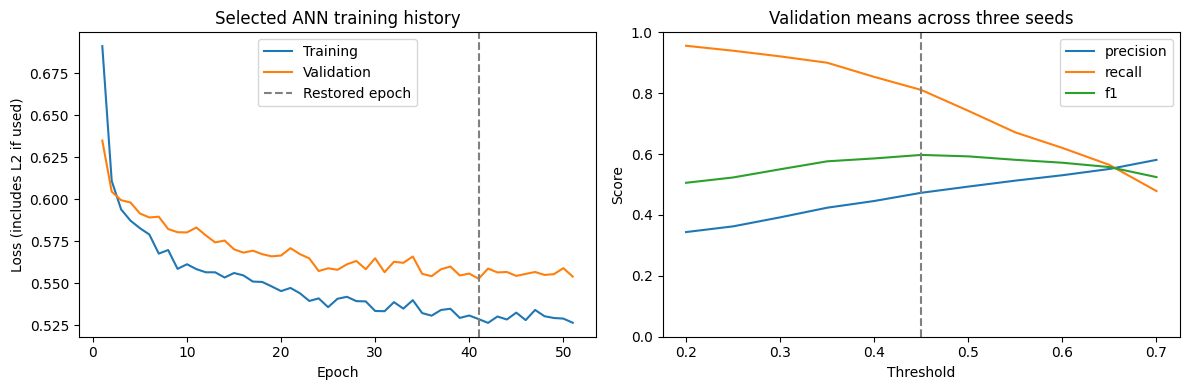

In [4]:
threshold_rows = []
for cfg in CONFIGS:
    for threshold in np.round(np.arange(0.20, 0.701, 0.05), 2):
        metric_rows = [scores(y_val_arr,
            (runs[(cfg['name'], seed)]['probabilities'] >= threshold).astype(int))
            for seed in SEEDS]
        threshold_rows.append({'configuration': cfg['name'], 'threshold': float(threshold),
            **{f'{metric}_mean': float(np.mean([r[metric] for r in metric_rows]))
               for metric in ['accuracy', 'precision', 'recall', 'f1']},
            'f1_sd': float(np.std([r['f1'] for r in metric_rows], ddof=1))})
search = pd.DataFrame(threshold_rows)
search['distance_from_050'] = (search['threshold'] - 0.5).abs()
search = search.sort_values(['f1_mean', 'precision_mean', 'distance_from_050', 'configuration'],
                            ascending=[False, False, True, True], kind='stable')
search.to_csv(OUT / 'validation_threshold_search.csv', index=False)
winner = search.iloc[0]
selected_name = str(winner['configuration'])
threshold = float(winner['threshold'])
selected_cfg = next(c for c in CONFIGS if c['name'] == selected_name)
model = tf.keras.models.load_model(OUT / f'candidate_{selected_name}.keras')
val_probabilities = model.predict(X_val, verbose=0).ravel()
np.testing.assert_allclose(val_probabilities, runs[(selected_name, SEED)]['probabilities'], atol=1e-6)
selected_val = scores(y_val_arr, (val_probabilities >= threshold).astype(int))
best_epoch = runs[(selected_name, SEED)]['best_epoch']
display(search.head(10).drop(columns='distance_from_050'))
print('LOCKED selection:', selected_name, '| threshold:', threshold, '| seed:', SEED)
print('Selected model validation metrics:', selected_val)
model.summary()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hist = runs[(selected_name, SEED)]['history']
epochs = np.arange(1, len(hist['loss']) + 1)
for key, label in [('loss', 'Training'), ('val_loss', 'Validation')]:
    axes[0].plot(epochs, hist[key], label=label)
axes[0].axvline(best_epoch, color='grey', linestyle='--', label='Restored epoch')
axes[0].set(title='Selected ANN training history', xlabel='Epoch', ylabel='Loss (includes L2 if used)')
axes[0].legend()
selected_search = search[search.configuration == selected_name].sort_values('threshold')
for metric in ['precision', 'recall', 'f1']:
    axes[1].plot(selected_search.threshold, selected_search[f'{metric}_mean'], label=metric)
axes[1].axvline(threshold, color='grey', linestyle='--')
axes[1].set(title='Validation means across three seeds', xlabel='Threshold', ylabel='Score', ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / 'training_and_threshold_selection.png', dpi=180)
plt.show()


## 4. Final test evaluation
The configuration, seed and threshold are now fixed. Run this section once for the review release. Test results must not be used to change the model. The majority baseline always predicts no churn; its churn-class precision is reported as zero by convention because it predicts no positives.

The bootstrap intervals below describe test-sample uncertainty for this fixed model. They do not include all sources of uncertainty, such as model selection, retraining or future population change.


,model,split,accuracy,precision,recall,f1
0,Always no churn,test,0.734618,0.000000,0.000000,0.000000
1,weighted_regularised_32_16,test,0.694589,0.457143,0.804469,0.582996


Test ROC AUC: 0.8127
Test average precision: 0.5957
TN=649, FP=342, FN=70, TP=288


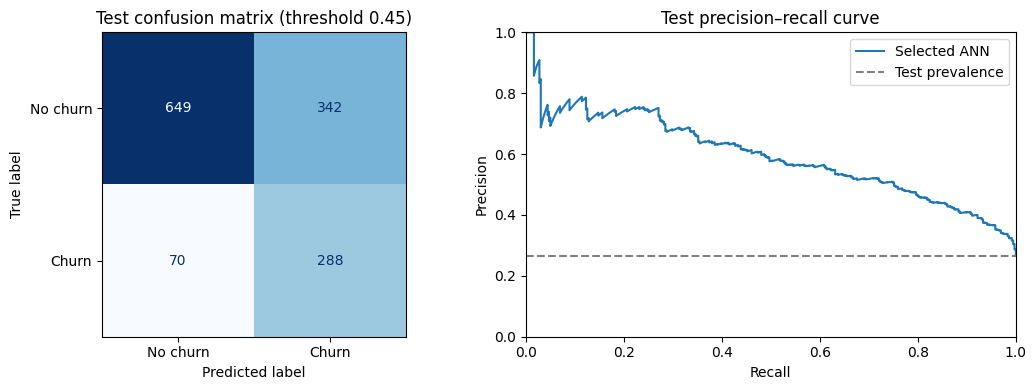

,metric,estimate,lower_95,upper_95
0,accuracy,0.694589,0.669385,0.716846
1,precision,0.457143,0.420460,0.495347
2,recall,0.804469,0.761489,0.844850
3,f1,0.582996,0.546571,0.618752


In [5]:
X_test = scaler.transform(X_test_raw).astype('float32')
y_test_arr = y_test.to_numpy(dtype='int32')
test_probabilities = model.predict(X_test, verbose=0).ravel()
test_predictions = (test_probabilities >= threshold).astype(int)
test_scores = scores(y_test_arr, test_predictions)
results = pd.DataFrame([
    {'model': 'Always no churn', 'split': 'test', **scores(y_test_arr, np.zeros(len(y_test_arr), dtype=int))},
    {'model': selected_name, 'split': 'test', **test_scores}
])
results.to_csv(OUT / 'final_test_metrics.csv', index=False)
display(results)
print('Test ROC AUC:', round(roc_auc_score(y_test_arr, test_probabilities), 4))
print('Test average precision:', round(average_precision_score(y_test_arr, test_probabilities), 4))
cm = confusion_matrix(y_test_arr, test_predictions, labels=[0, 1])
tn, fp, fn, tp = [int(v) for v in cm.ravel()]
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Test confusion matrix (threshold {threshold:.2f})')
precision_curve, recall_curve, _ = precision_recall_curve(y_test_arr, test_probabilities)
axes[1].plot(recall_curve, precision_curve, label='Selected ANN')
axes[1].axhline(y_test_arr.mean(), color='grey', linestyle='--', label='Test prevalence')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Test precision–recall curve', xlim=(0, 1), ylim=(0, 1))
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG / 'test_evaluation.png', dpi=180)
plt.show()

rng = np.random.default_rng(SEED)
bootstrap = []
for _ in range(1000):
    ix = rng.integers(0, len(y_test_arr), len(y_test_arr))
    bootstrap.append(scores(y_test_arr[ix], test_predictions[ix]))
bootstrap = pd.DataFrame(bootstrap)
intervals = pd.DataFrame({'metric': list(test_scores), 'estimate': list(test_scores.values()),
    'lower_95': [bootstrap[m].quantile(.025) for m in test_scores],
    'upper_95': [bootstrap[m].quantile(.975) for m in test_scores]})
intervals.to_csv(OUT / 'test_metric_intervals.csv', index=False)
display(intervals)
pd.DataFrame({'source_row_index': X_test_raw.index, 'actual_churn': y_test_arr,
    'predicted_churn_probability': test_probabilities, 'predicted_churn': test_predictions}
    ).to_csv(OUT / 'test_predictions.csv', index=False)


## 5. Explain model reliance and describe customer patterns
Grouped permutation importance is measured on **validation** as the drop in average precision when a related feature group is shuffled together. Derived tenure/spend features are grouped to reduce misleading rankings from redundancy. The broad group still cannot isolate an individual variable's effect. Negative importance may reflect noise; error bars are repeat-to-repeat standard deviations, not confidence intervals.

The profiles use development data (fit + validation), not test, and show observed associations. High average precision importance does not establish direction or causation. Use profiles alongside model reliance, and coordinate with Abed's separate clustering results; this ANN does not perform customer segmentation.


,feature_group,mean_ap_drop,sd_ap_drop
0,"Tenure, charges and derived spending",0.309699,0.013013
3,Phone and multiple lines,0.017893,0.006669
5,Senior citizen,0.007565,0.008490
1,Contract,0.004155,0.002686
2,Internet service,0.001256,0.002570
4,Dependents,0.000995,0.007887
6,Gender,-0.000234,0.005367


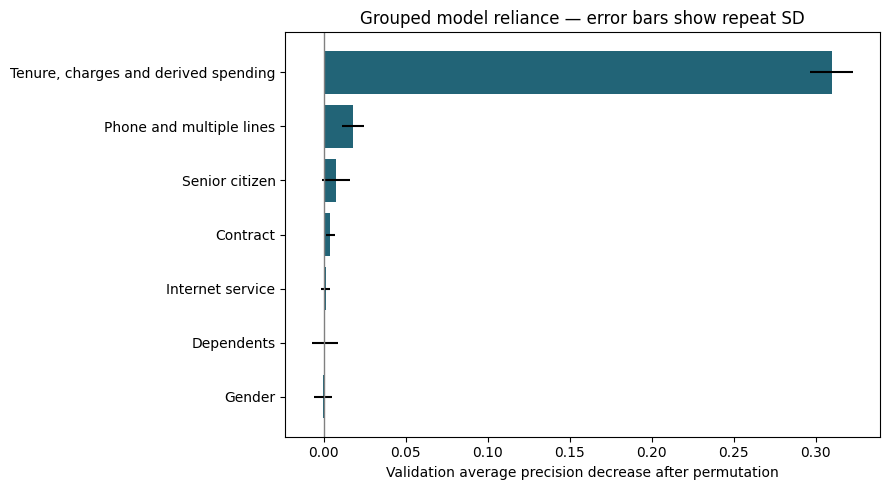

,factor,category,count,observed_churn_rate
0,Tenure band,0–12 months,1579,0.490184
1,Tenure band,13–24 months,817,0.286414
2,Tenure band,25–48 months,1253,0.209098
3,Tenure band,49+ months,1743,0.093517
4,Contract group,One year,1153,0.251518
5,Contract group,Reference contract category,2877,0.277025
6,Contract group,Two year,1362,0.254038


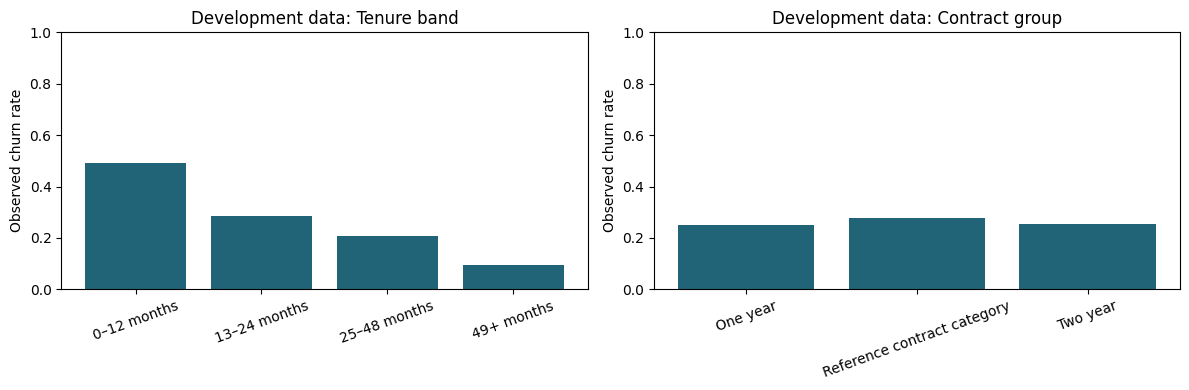

In [6]:
groups = {
    'Tenure, charges and derived spending': [c for c in feature_names if c in
        ['tenure', 'MonthlyCharges', 'EstimatedTotalSpend', 'NumActiveServices', 'AvgMonthlyChargePerService']
        or c.startswith('TenureGroup_')],
    'Contract': [c for c in feature_names if c.startswith('Contract_')],
    'Internet service': [c for c in feature_names if c.startswith('InternetService_')],
    'Phone and multiple lines': [c for c in feature_names if c.startswith(('PhoneService_', 'MultipleLines_'))],
    'Dependents': [c for c in feature_names if c.startswith('Dependents_')],
    'Senior citizen': ['SeniorCitizen'],
    'Gender': [c for c in feature_names if c.startswith('gender_')],
}
assert sorted(c for cols in groups.values() for c in cols) == sorted(feature_names)
base_ap = average_precision_score(y_val_arr, val_probabilities)
rng = np.random.default_rng(SEED)
importance_rows = []
for group, cols in groups.items():
    indices = [feature_names.index(c) for c in cols]
    drops = []
    for repeat in range(10):
        shuffled = X_val.copy()
        perm = rng.permutation(len(shuffled))
        shuffled[:, indices] = X_val[perm][:, indices]
        p = model.predict(shuffled, verbose=0).ravel()
        drops.append(base_ap - average_precision_score(y_val_arr, p))
    importance_rows.append({'feature_group': group, 'mean_ap_drop': np.mean(drops),
                            'sd_ap_drop': np.std(drops, ddof=1)})
importance = pd.DataFrame(importance_rows).sort_values('mean_ap_drop', ascending=False)
importance.to_csv(OUT / 'grouped_feature_importance.csv', index=False)
display(importance)
plot_data = importance.iloc[::-1]
plt.figure(figsize=(9, 5))
plt.barh(plot_data.feature_group, plot_data.mean_ap_drop, xerr=plot_data.sd_ap_drop, color='#226477')
plt.axvline(0, color='grey', linewidth=1)
plt.xlabel('Validation average precision decrease after permutation')
plt.title('Grouped model reliance — error bars show repeat SD')
plt.tight_layout()
plt.savefig(FIG / 'grouped_feature_importance.png', dpi=180)
plt.show()

profiles = X_train_raw.copy()
profiles['Churn'] = y_train.to_numpy()
profiles['Tenure band'] = pd.cut(profiles.tenure, [-np.inf, 12, 24, 48, np.inf],
    labels=['0–12 months', '13–24 months', '25–48 months', '49+ months'])
profiles['Contract group'] = np.select(
    [profiles['Contract_One year'] == 1, profiles['Contract_Two year'] == 1],
    ['One year', 'Two year'], default='Reference contract category')
profile_tables = []
for field in ['Tenure band', 'Contract group']:
    table = profiles.groupby(field, observed=True).Churn.agg(['count', 'mean']).reset_index()
    table.columns = ['category', 'count', 'observed_churn_rate']
    table.insert(0, 'factor', field)
    profile_tables.append(table)
profile_summary = pd.concat(profile_tables, ignore_index=True)
profile_summary.to_csv(OUT / 'development_customer_profiles.csv', index=False)
display(profile_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, table, field in zip(axes, profile_tables, ['Tenure band', 'Contract group']):
    ax.bar(table.category.astype(str), table.observed_churn_rate, color='#226477')
    ax.set(title=f'Development data: {field}', ylabel='Observed churn rate', ylim=(0, 1))
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIG / 'development_profiles.png', dpi=180)
plt.show()


## 6. Save and verify the handoff model
Save the exact model evaluated on test, preprocessing parameters and feature order. Verify reloaded predictions match. The inference helper accepts **Tyler-style encoded, unscaled features**, not raw customer categories and not the already-scaled CSVs. Applying scaling twice would produce incorrect predictions.


In [7]:
model.save(OUT / 'ann_final.keras')
np.savez(OUT / 'scaler_parameters.npz', mean=scaler.mean_, scale=scaler.scale_)
metadata = {
    'status': 'review_release_pending_team_feedback', 'data_version': DATA_VERSION,
    'source_sha256': source_hashes, 'feature_columns': feature_names,
    'input_contract': 'Encoded unscaled features matching Tyler preprocessed dataset; exclude Churn',
    'configuration': selected_cfg, 'threshold': threshold, 'seed': SEED, 'comparison_seeds': SEEDS,
    'selection_rule': 'Highest mean validation F1; ties higher precision then nearest 0.50 threshold',
    'best_epoch': best_epoch, 'training_rows': len(X_fit), 'validation_rows': len(X_val),
    'test_rows': len(X_test), 'refit_on_all_training_rows': False,
    'test_metrics': test_scores, 'test_confusion_matrix': cm.tolist(),
    'test_roc_auc': float(roc_auc_score(y_test_arr, test_probabilities)),
    'test_average_precision': float(average_precision_score(y_test_arr, test_probabilities)),
    'versions': {'python': platform.python_version(), 'tensorflow': tf.__version__,
                 'numpy': np.__version__, 'pandas': pd.__version__, 'scikit-learn': sklearn.__version__},
    'run_id_utc': RUN_ID,
}
(OUT / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
reloaded = tf.keras.models.load_model(OUT / 'ann_final.keras', compile=False)
with np.load(OUT / 'scaler_parameters.npz') as params:
    reloaded_X = ((X_test_raw.to_numpy() - params['mean']) / params['scale']).astype('float32')
np.testing.assert_allclose(reloaded.predict(reloaded_X, verbose=0).ravel(),
                           test_probabilities, atol=1e-6)
print('Reload check passed: saved model and scaler reproduce test predictions.')
helper = """import json
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf

def predict_churn(encoded_unscaled_features, artifact_dir):
    root = Path(artifact_dir)
    meta = json.loads((root / 'metadata.json').read_text())
    expected = meta['feature_columns']
    if set(encoded_unscaled_features.columns) != set(expected):
        raise ValueError('Provide exactly the documented encoded, unscaled features, without Churn.')
    x = encoded_unscaled_features[expected].to_numpy(dtype=float)
    if not np.isfinite(x).all():
        raise ValueError('Input contains missing or non-finite values.')
    with np.load(root / 'scaler_parameters.npz') as params:
        x = ((x - params['mean']) / params['scale']).astype('float32')
    model = tf.keras.models.load_model(root / 'ann_final.keras', compile=False)
    p = model.predict(x, verbose=0).ravel()
    return pd.DataFrame({'churn_probability': p,
        'predicted_churn': (p >= meta['threshold']).astype(int)},
        index=encoded_unscaled_features.index)
"""
(OUT / 'predict_churn.py').write_text(helper, encoding='utf-8')
(OUT / 'requirements.txt').write_text('\n'.join(
    f'{package}=={version}' for package, version in metadata['versions'].items() if package != 'python'
) + '\n', encoding='utf-8')


Reload check passed: saved model and scaler reproduce test predictions.


66

## 7. Architecture document and findings for Arafat
The following files are generated from this run, not invented results. Review the English brief and PDF layout before submission. Recommendations are proposals for testing, not demonstrated retention gains. The group must add Abed's segmentation findings, final business recommendations, and the video separately.


In [8]:
def save_text_pdf(path, title, paragraphs):
    # Simple paginated text document for portable review.
    lines = []
    for paragraph in paragraphs:
        for logical_line in str(paragraph).splitlines():
            lines.extend(textwrap.wrap(logical_line, width=92, break_long_words=True) or [''])
        lines.append('')
    with PdfPages(path) as pdf:
        for start in range(0, max(len(lines), 1), 43):
            fig = plt.figure(figsize=(8.27, 11.69))
            fig.text(.09, .94, title, fontsize=16, weight='bold', va='top')
            fig.text(.09, .88, '\n'.join(lines[start:start+43]), fontsize=10,
                     va='top', linespacing=1.5, family='DejaVu Sans')
            fig.text(.09, .045, f'Felix | Stage 3 | Review release | Page {start//43+1}', fontsize=8)
            pdf.savefig(fig)
            plt.close(fig)

architecture_paragraphs = [
    'This document describes the trained ANN supplied for team review. Its saved weights are the same weights used for the reported test evaluation.',
    f"Selected configuration: {selected_name}. Input layer: {len(feature_names)} encoded numerical features. Hidden layers: {selected_cfg['hidden']} with ReLU activation. Output: one sigmoid neuron producing a churn score between zero and one. These scores have not been independently calibrated.",
    f"Dropout after each hidden layer: {selected_cfg['dropout']}. L2 coefficient on hidden-layer kernels: {selected_cfg['l2']}. Trainable parameters: {model.count_params()}.",
    f"Adam learning rate 0.001; binary crossentropy; batch size 32; maximum 80 epochs; early stopping on validation loss with patience 10 and restored weights. Retained epoch: {best_epoch}. Balanced class weights used: {selected_cfg['weighted']}.",
    f"Training subset: {len(X_fit)}. Validation: {len(X_val)}. Test: {len(X_test)}. The StandardScaler was fitted only on the training subset. No refit was performed after selection.",
    f"Three configurations were compared across seeds {SEEDS}. Selection maximised mean validation F1 over thresholds 0.20 to 0.70 in steps of 0.05. Delivered seed: 42. Selected threshold: {threshold:.2f}. Mean validation F1 for the selected pair: {winner['f1_mean']:.4f}; seed SD: {winner['f1_sd']:.4f}.",
    f"Pinned source commit: {DATA_VERSION}. Input columns in order: " + ', '.join(feature_names),
    'Inference requires encoded unscaled features. Use predict_churn.py with ann_final.keras, scaler_parameters.npz and metadata.json. Do not apply the scaler to already-standardised data.',
    'The original preprocessing and duplicate-removal policy are inherited. A customer identifier is not available. Generalisation to new populations and causal effects have not been established.'
]
save_text_pdf(OUT / 'ANN_Architecture.pdf', 'ANN Architecture', architecture_paragraphs)

positive_importance = importance[importance.mean_ap_drop > 0]
top_groups = ', '.join(positive_importance.head(3).feature_group) or 'No positive importance groups in this run'
metric_text = '; '.join(f'{k}: {v:.2%}' for k, v in test_scores.items())
findings = [
    f"Test performance: {metric_text}. These are test results for a configuration and threshold selected using validation only, on {len(y_test_arr)} test records.",
    f"The model identified {tp} of {tp+fn} actual churners, missed {fn}, and generated {fp} false alerts. It correctly classified {tn} non-churners. The always-no-churn baseline accuracy is {(y_test_arr==0).mean():.2%}; that baseline identifies no churners.",
    f"Selected model: {selected_name}, hidden layers {selected_cfg['hidden']}, sigmoid output, threshold {threshold:.2f}, seed 42, restored epoch {best_epoch}. Selection used mean validation F1 across three seeds. See validation_threshold_search.csv for all comparisons; do not interpret seed variation as cross-validation.",
    f"Largest positive grouped validation AP decreases: {top_groups}. These are groups the model relies on, not proof of causal drivers or direction of influence. Correlated engineered features were grouped, so their individual effects cannot be separated here.",
    'Development profiles in development_customer_profiles.csv describe observed churn rates by tenure band and encoded contract group. Read them alongside grouped importance and Abed\'s independent clustering findings. The reference contract label must be verified against Tyler\'s encoding before naming it in the report.',
    'Recommendation for team discussion: use the score to prioritise a small retention pilot within a defined contact budget. Review false-positive workload and missed churners before operational use. Compare targeted interventions with a control group; no retention uplift or financial benefit has been demonstrated by this model.',
    'Additional recommendation: consider offers or service reviews only where the observed profiles and business context support them. Feature importance alone does not justify a specific discount or prove why customers left. Gender and age-related inputs should not automatically determine offers; review suitability and performance across relevant groups before deployment.',
    'Limitations: one reduced historical dataset, inherited deduplication without customer IDs, a single fixed train/validation/test split, possible validation selection optimism, correlated features, and uncalibrated sigmoid scores. No temporal/external validation or causal evaluation. Bootstrap intervals quantify test-sample uncertainty for this fixed model only.',
    'Proposed improvements: confirm the duplicate policy and reference categories with Tyler; collect richer and time-stamped features; evaluate on future data; assess calibration and business costs; monitor drift and relevant subgroup performance. These are future actions, not completed checks.',
    'Handoff status: review release. Arafat can use these findings and figures to draft the predictive-modelling sections. The team still needs to review wording, integrate segmentation results, complete the final report and record the 10–15 minute group demonstration. PM submits the team package.'
]
(OUT / 'Findings_for_Arafat.md').write_text('# Predictive modelling findings\n\n' +
    '\n\n'.join(findings), encoding='utf-8')
save_text_pdf(OUT / 'Findings_for_Arafat.pdf', 'Predictive Modelling Findings', findings)
readme = f"""# Predictive modelling review release

Run ID (UTC): {RUN_ID}
Data commit: {DATA_VERSION}

## Main files
- ANN_Architecture.pdf: required architecture document.
- ann_final.keras: trained model evaluated on test.
- scaler_parameters.npz and metadata.json: matching preprocessing, feature order and threshold.
- predict_churn.py: inference on encoded unscaled features.
- final_test_metrics.csv and test_metric_intervals.csv: evaluation and uncertainty.
- test_predictions.csv: probabilities and labels; source_row_index is not a customer ID.
- validation_runs_at_050.csv and validation_threshold_search.csv: model selection evidence.
- grouped_feature_importance.csv and development_customer_profiles.csv: interpretation evidence.
- figures/: training, threshold, test and interpretation graphics.
- Findings_for_Arafat.md and .pdf: report input for team review.
- requirements.txt: versions used by this run.

## Reproduce and submit
Add the executed ANN_Churn_Prediction_Stage3.ipynb notebook to this folder after downloading it from Colab. Run it top to bottom with the pinned source data. Outputs can vary across platforms and library versions.

The deployed input contract here means Tyler-style encoded unscaled features, not raw categorical customer records and not already-scaled features. No web application or production deployment is supplied.

The selected model was trained on 4,313 rows, with 1,079 validation rows. The 1,349 test rows were used after selection. Do not tune using test outcomes. Candidate model files are retained as audit evidence; ann_final.keras is the selected model.

Before submission: inspect the PDFs and figures, check agreement across report and results, integrate Abed's clustering, have Arafat review findings, and prepare the group video. Put these deliverables in Predictive_Modeling in the existing team repository. The PM submits the group report, repository link and video.
"""
(OUT / 'README.md').write_text(readme, encoding='utf-8')
print('Architecture PDF and Arafat findings generated. Review them before submission.')
print('\n'.join(findings[:4]))


Architecture PDF and Arafat findings generated. Review them before submission.
Test performance: accuracy: 69.46%; precision: 45.71%; recall: 80.45%; f1: 58.30%. These are test results for a configuration and threshold selected using validation only, on 1349 test records.
The model identified 288 of 358 actual churners, missed 70, and generated 342 false alerts. It correctly classified 649 non-churners. The always-no-churn baseline accuracy is 73.46%; that baseline identifies no churners.
Selected model: weighted_regularised_32_16, hidden layers [32, 16], sigmoid output, threshold 0.45, seed 42, restored epoch 41. Selection used mean validation F1 across three seeds. See validation_threshold_search.csv for all comparisons; do not interpret seed variation as cross-validation.
Largest positive grouped validation AP decreases: Tenure, charges and derived spending, Phone and multiple lines, Senior citizen. These are groups the model relies on, not proof of causal drivers or direction of in

## 8. Download and team handoff
Run the next cell to download the complete output ZIP. Then use **File → Download → Download .ipynb** to save this notebook with its executed outputs. The ZIP cannot automatically capture the live Colab notebook, so add it separately to the team's `Predictive_Modeling` folder.

Send the ZIP and executed notebook back for review before uploading. Keep the old draft separate. Do not report any generated result as approved by the team until reviewed. The group report and 10–15 minute video are separate deliverables.


In [9]:
required = ['ann_final.keras', 'scaler_parameters.npz', 'metadata.json',
            'ANN_Architecture.pdf', 'Findings_for_Arafat.pdf', 'final_test_metrics.csv',
            'test_predictions.csv', 'grouped_feature_importance.csv', 'README.md']
assert all((OUT / name).is_file() for name in required)
archive = shutil.make_archive(str(OUT.parent / f'ANN_Stage3_Review_{RUN_ID}'),
                              'zip', root_dir=OUT.parent, base_dir=OUT.name)
print('Review package:', archive)
print('Remember to download the executed notebook separately.')
from google.colab import files
files.download(archive)


Review package: /content/ann_stage3_runs/20261005T040331Z/ANN_Stage3_Review_20261005T040331Z.zip
Remember to download the executed notebook separately.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>